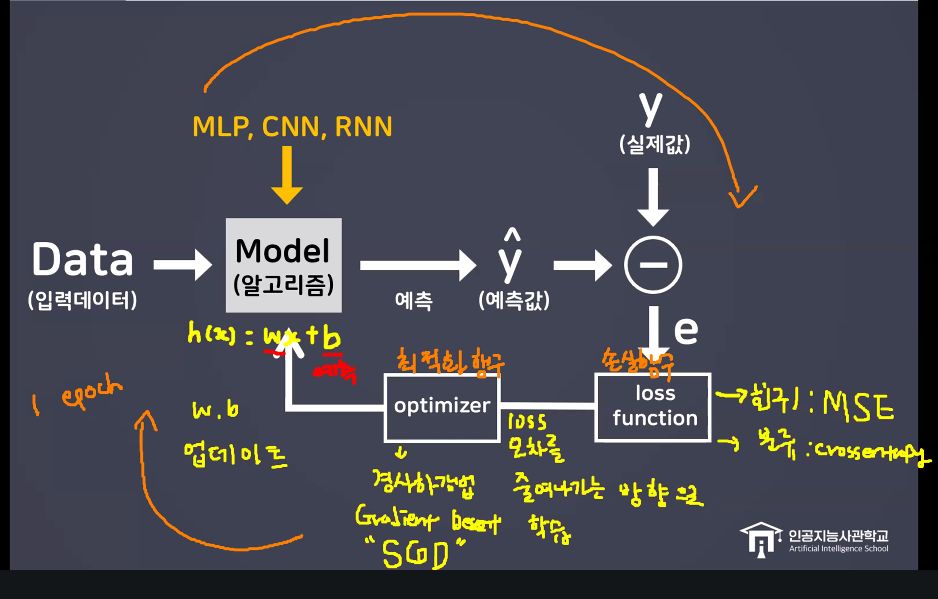 

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
x = np.array([[2,0],[4,4],[6,2],[8,3]])
y = np.array([81, 93, 91, 97])

In [ ]:

# 출력 값, 입력 변수, 분석 방법에 맞게끔 모델을 설정합니다. 
# model.add(Dense(1, input_dim=2, activation='linear'))
# model.add(Dense(1, input_shape=(2,), activation='linear'))
# model.add(Dense(1, Input(shape=(2,)), activation='linear'))

model = Sequential([
    Input(shape=(2,)),  # 입력 특성 (feature)이 2개 (공부시간, 운동시간)
    Dense(1,activation="linear")
])

# 공부 시간 : x1, 운동시간 : x2 라고 하면, layer에 y = w1x1 + w2x2 + b이라는 다항식이 생김

model.compile(optimizer="sgd",loss="mse")

model.fit(x,y,epochs=1000) # 어느순간부터 비슷한 숫자의 loss 값을 보이고 정체되는 구간이 있음 그러면 학습이 끝난 것으로 판별

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 7672.6772
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1401.4323
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 954.9141
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 918.0826
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 910.0989
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 904.1784
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 898.4371
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 892.7422
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 887.0843
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 881.4625
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 875.8764
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 870.3259
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 864.8105
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 859.3303
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [5]:
weights, bias = model.layers[0].get_weights()

print(weights)
print(bias)

[[1.9602684]
 [2.4446352]]
[74.69694]


In [ ]:
model.summary() # param : 파라미터 3개는 w1,w2,b 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [14]:
# 예측
pred = model.predict(np.array([[10,5],[12,5]]))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[106.5228 ]
 [110.44333]]


In [15]:
# 경사하강법 직접 구현

# 오차 계산 → 기울기 계산 → 가중치 수정 → 반복

w = 10
lr = 0.1

for epoch in range(20):

    loss = (w-3)**2    
    grad = 2 * (w-3) # 위의 미분
    
    #새 가중치 = 기존 가중치 - 학습률×기울기
    w = w - lr * grad 

    print(epoch,round(w,3),round(loss,3))

0 8.6 49
1 7.48 31.36
2 6.584 20.07
3 5.867 12.845
4 5.294 8.221
5 4.835 5.261
6 4.468 3.367
7 4.174 2.155
8 3.94 1.379
9 3.752 0.883
10 3.601 0.565
11 3.481 0.362
12 3.385 0.231
13 3.308 0.148
14 3.246 0.095
15 3.197 0.061
16 3.158 0.039
17 3.126 0.025
18 3.101 0.016
19 3.081 0.01


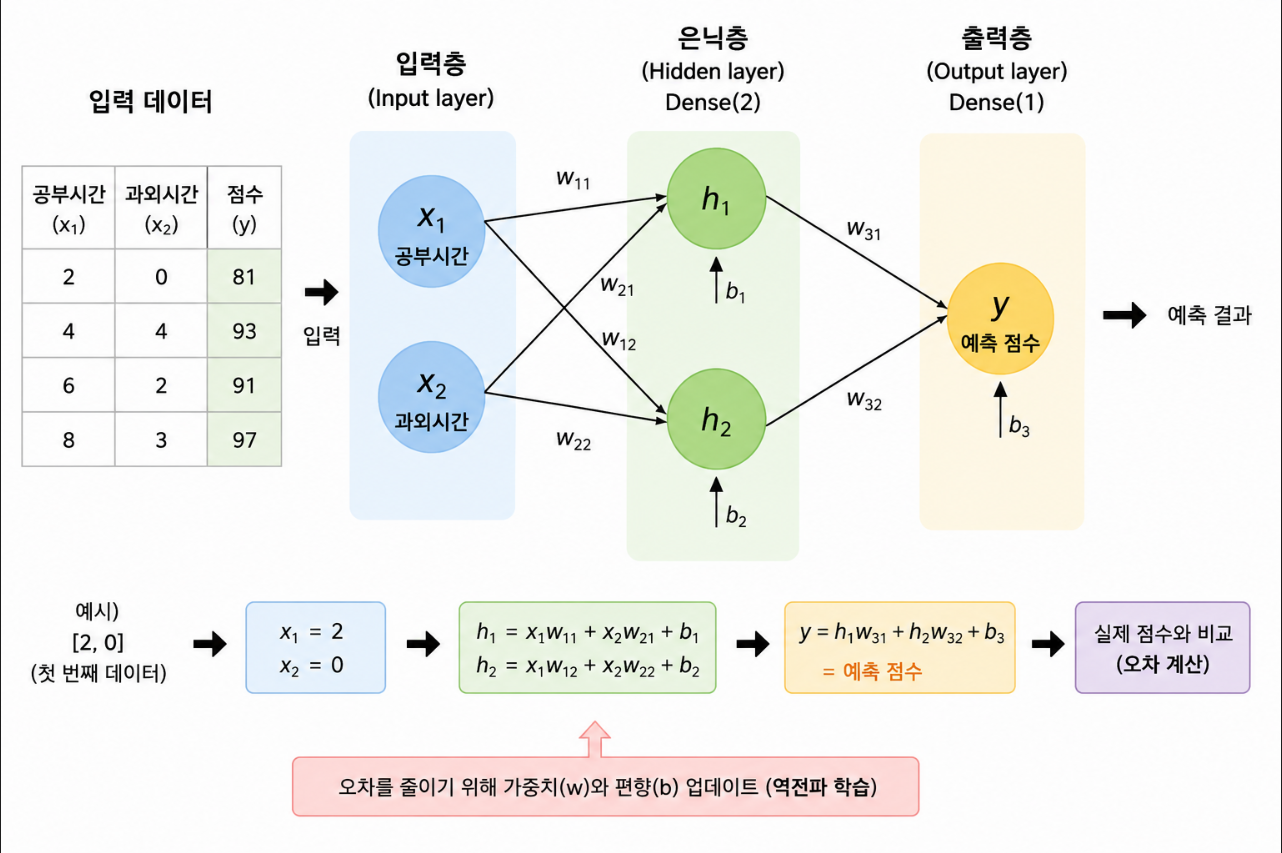

In [26]:
# 다항 문제
# 문제  광고비 + 영업사원수 → 매출

import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# ==========================
# 데이터
# 광고비, 영업사원수
# ==========================

x = np.array([
    [10, 2],
    [20, 3],
    [30, 4],
    [40, 5]
])

# 매출
y = np.array([
    100,
    180,
    260,
    340
])

# 예측
# 광고비=35
# 영업사원수=4

model = Sequential([
    Input(shape=(2,)),
    Dense(2,activation="linear"),
    Dense(1,activation="linear")
])

model.compile(optimizer="adam",loss="mse")

model.fit(x,y,epochs=1000,verbose=1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - loss: 58279.0625
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 58264.0195
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 58249.0469
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 58234.1484
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 58219.3047
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 58204.5312
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 58189.8320
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 58175.1953
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 58160.6250
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 58146.1211
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 58131.6797
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 58117.2969
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 58102.9688
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 58088.6797
Epoch 15/1000


In [27]:
# 가중치 바이어스 확인 
weights, bias = model.layers[0].get_weights()

print(weights)
print(bias)

[[1.5626978 1.3123975]
 [2.5019696 1.8710475]]
[1.4736956  0.85885787]


In [28]:
# 예측
pred = model.predict(np.array([[35,4]]))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[135.98935]]
